In [399]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


In [400]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [401]:
filepath = "/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt"

with open(filepath,'r') as file:
    content = file.read()
# print(content) - data description

In [402]:
train = pd.read_csv('../input/house-prices-advanced-regression-techniques/train.csv')
print(train.shape)
train.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [403]:
test = pd.read_csv('../input/house-prices-advanced-regression-techniques/test.csv')
print(test.shape)
test.head()

(1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [404]:
# concating test and train for EDA
df = pd.concat([train,test],ignore_index=True)

In [405]:
print(train.shape)
print(test.shape)
print(df.shape)

(1460, 81)
(1459, 80)
(2919, 81)


In [406]:
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)
pd.set_option("display.width",None)

## Null treatment

In [407]:
# Test set doesnt have saleprice col, since we concated train and test sale price would be null, so imputed with zero
df.loc[1460:,'SalePrice'] = int(0)

In [408]:
# filtering columns with null values greater than 20% 
null= df.isnull().sum()
null_20perc = null[(null/df.shape[0] * 100)>20]/df.shape[0]
print(null_20perc) 
cols_to_drop = null_20perc.index.to_list()
cols_to_drop

Alley          0.932169
MasVnrType     0.605002
FireplaceQu    0.486468
PoolQC         0.996574
Fence          0.804385
MiscFeature    0.964029
dtype: float64


['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']

In [409]:
# Drop columns with more than 20% null values
print(df.shape, " before dropping")
df = df.drop(columns=cols_to_drop,axis=1)
print(df.shape, " after dropping")

(2919, 81)  before dropping
(2919, 75)  after dropping


In [410]:
others = null[(null.values>0) & (~null.index.isin(null_20perc.index))]
other_null_cols = others.index.to_list()
print(other_null_cols)

['MSZoning', 'LotFrontage', 'Utilities', 'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Electrical', 'BsmtFullBath', 'BsmtHalfBath', 'KitchenQual', 'Functional', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'SaleType']


In [411]:
# Impute with median and mode for other null columns
for col in other_null_cols:
    if np.issubdtype(df[col].dtype,np.number):
        df[col].fillna(df[col].median(),inplace=True)
    else:
        df[col].fillna(df[col].mode()[0],inplace=True)

In [412]:
df.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
RoofStyle        0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
MasVnrArea       0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinSF1       0
BsmtFinType2     0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
KitchenQual      0
TotRmsAbvGrd

In [413]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000
mean,1460.000000,57.137718,69.088386,10168.114080,6.089072,5.564577,1971.312778,1984.264474,101.396026,441.398253,49.565262,560.739979,1051.756252,1159.581706,336.483727,4.694416,1500.759849,0.429599,0.061322,1.568003,0.380267,2.860226,1.044536,6.451524,0.597122,1978.161699,1.766701,472.877013,93.709832,47.486811,23.098321,2.602261,16.062350,2.251799,50.825968,6.213087,2007.792737,90491.588215
std,842.787043,42.517628,21.317898,7886.996359,1.409947,1.113131,30.291442,20.894344,178.854579,455.534750,169.179104,439.471764,440.692234,392.362079,428.701456,46.396825,506.051045,0.524676,0.245608,0.552969,0.502872,0.822693,0.214462,1.569379,0.646129,24.868576,0.761506,215.357944,126.526589,67.575493,64.244246,25.188169,56.184365,35.663946,567.402211,2.714762,1.314964,106496.379333
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,0.000000
25%,730.500000,20.000000,60.000000,7478.000000,5.000000,5.000000,1953.500000,1965.000000,0.000000,0.000000,0.000000,220.000000,793.000000,876.000000,0.000000,0.000000,1126.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.500000,1.000000,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,0.000000
50%,1460.000000,50.000000,68.000000,9453.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,368.500000,0.000000,467.000000,989.500000,1082.000000,0.000000,0.000000,1444.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1979.000000,2.000000,480.000000,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,34900.000000
75%,2189.500000,70.000000,78.000000,11570.000000,7.000000,6.000000,2001.000000,2004.000000,163.500000,733.000000,0.000000,805.000000,1302.000000,1387.500000,704.000000,0.000000,1743.500000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2001.000000,2.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,163000.000000
max,2919.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.000000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [414]:
df.describe(include='O')

,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
count,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919,2919
unique,5,2,4,4,2,5,3,25,9,8,5,8,6,8,15,16,4,5,6,4,4,4,6,6,6,5,2,5,4,7,6,3,5,5,3,9,6
top,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,TA,TA,PConc,TA,TA,No,Unf,Unf,GasA,Ex,Y,SBrkr,TA,Typ,Attchd,Unf,TA,TA,Y,WD,Normal
freq,2269,2907,1859,2622,2918,2133,2778,443,2511,2889,2425,1471,2310,2876,1026,1015,1798,2538,1308,1364,2688,1986,930,2573,2874,1493,2723,2672,1493,2719,1880,1389,2763,2813,2641,2526,2402


## Univariate Analysis

In [415]:
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [416]:
cat_cols=df.select_dtypes(exclude=np.number).columns
cat_cols

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
       'SaleType', 'SaleCondition'],
      dtype='object')

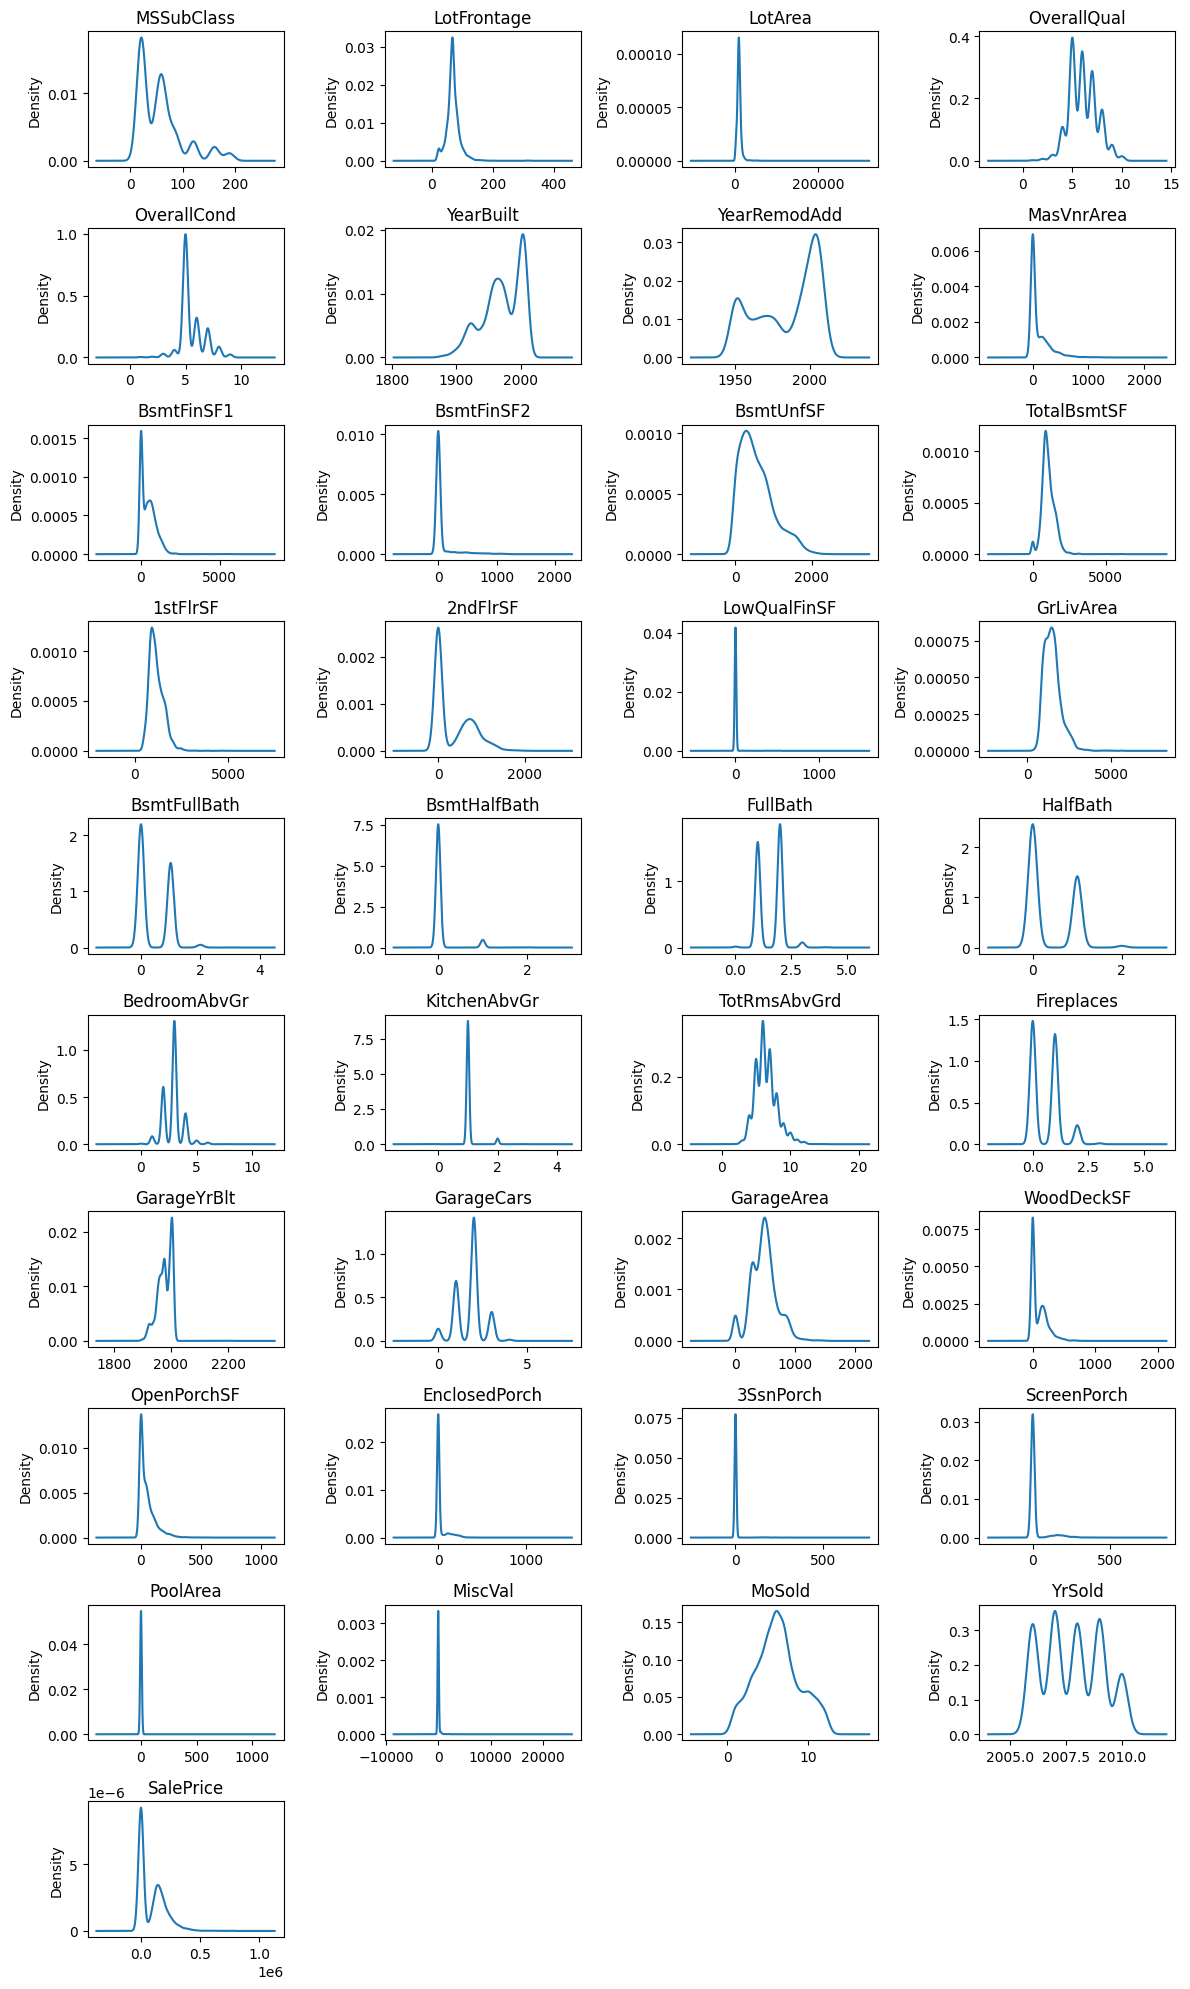

In [417]:
n_cols = 4  # Number of columns in subplot layout
n_rows = (len(num_cols) + n_cols - 1) // n_cols  # Calculate rows needed

plt.figure(figsize=(12, n_rows * 2))  # Adjust figure size as needed

for k, i in enumerate(num_cols[1:]): #num_cols from 1st index to ignore 'id' column as it is identifier
    plt.subplot(n_rows, n_cols, k + 1)  # Create subplots
    df[i].plot(kind='kde')
    plt.title(i)

plt.tight_layout()  
plt.show() 

In [418]:
# All the numerical variable is not normally distributed, so we can proceed with tree / ensemble models

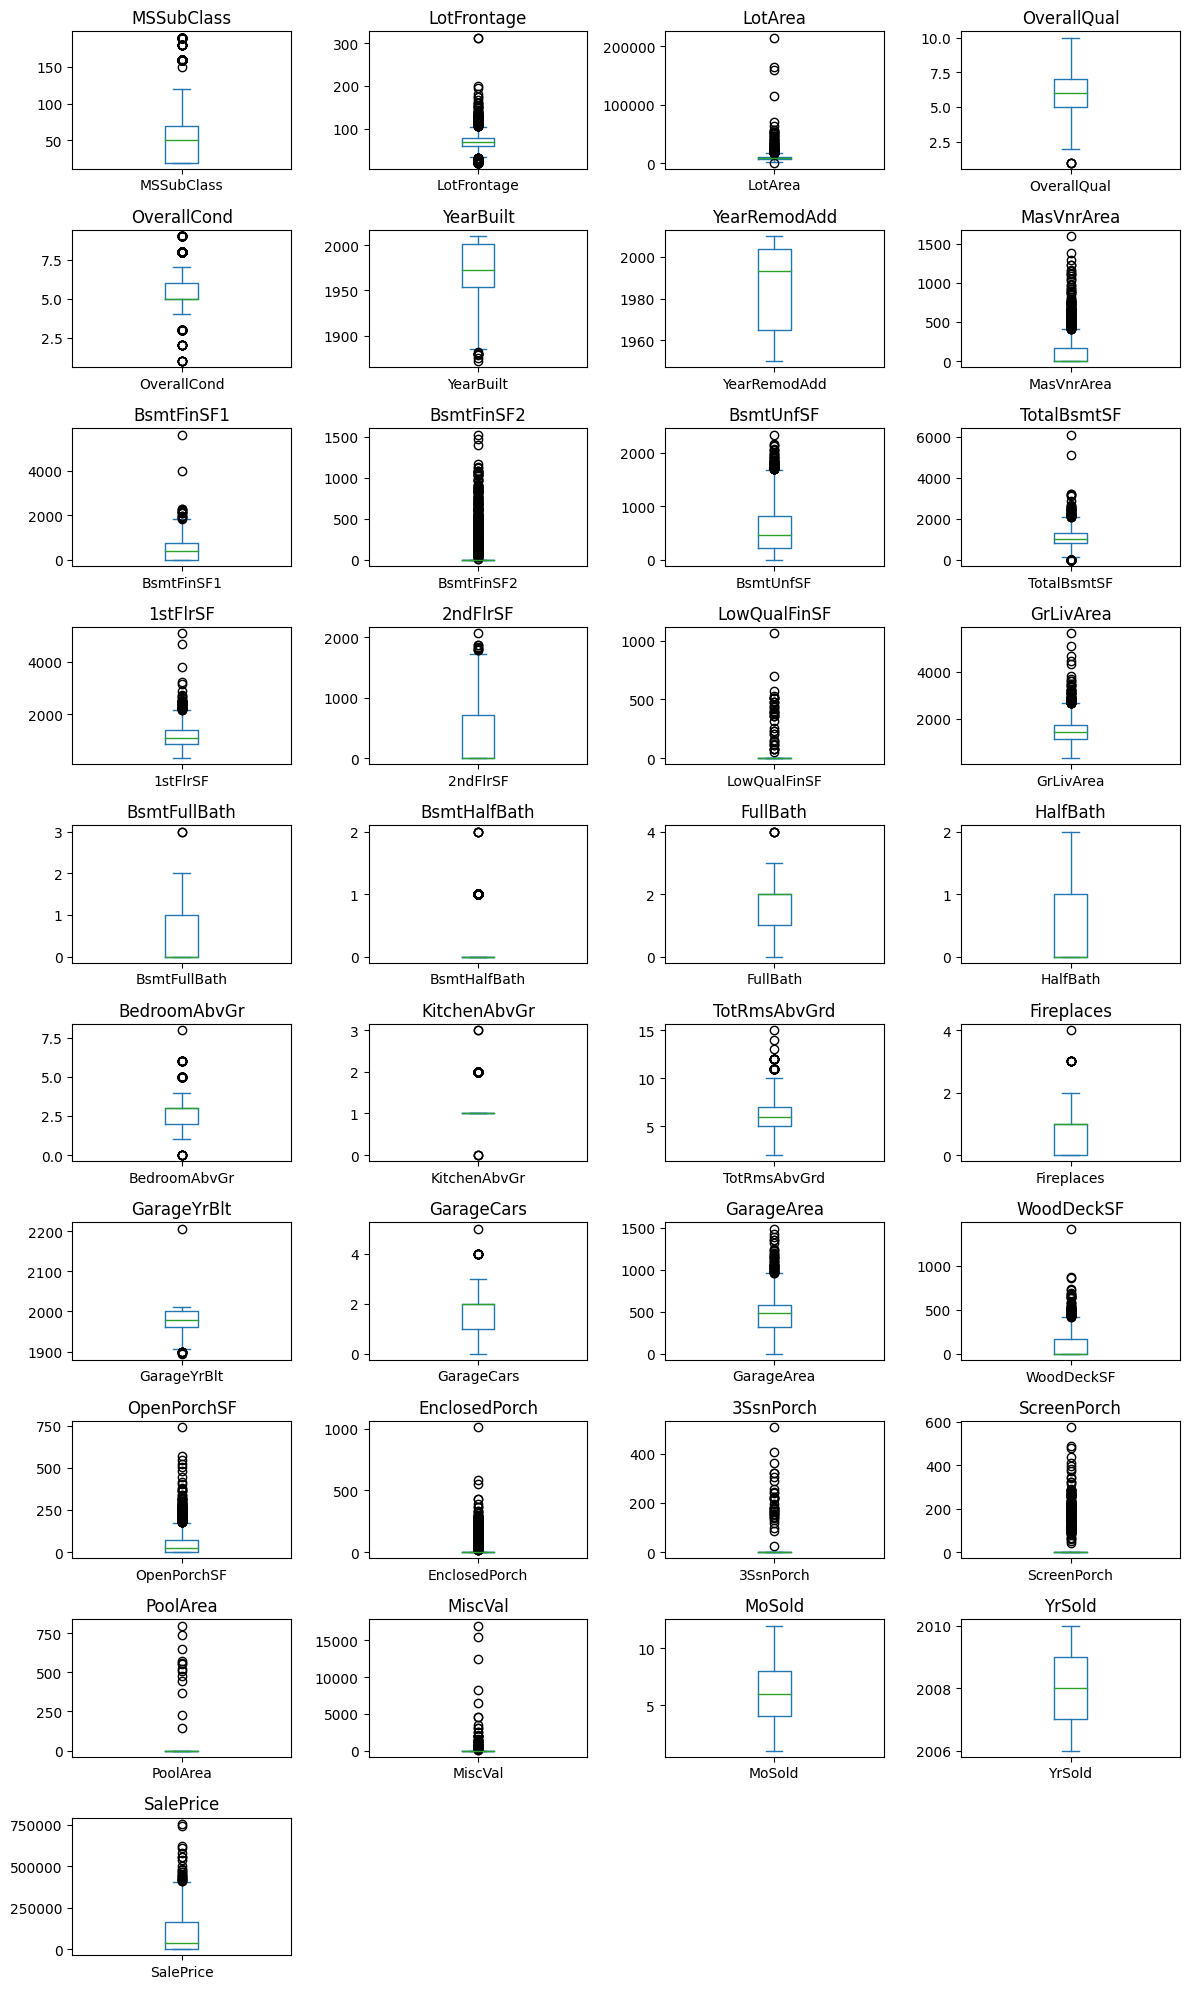

In [419]:
# Outlier Detection using Box Plot
n_cols = 4  # Number of columns in subplot layout
n_rows = (len(num_cols) + n_cols - 1) // n_cols  # Calculate rows needed

plt.figure(figsize=(12, n_rows * 2))  # Adjust figure size as needed

for k, i in enumerate(num_cols[1:]): #num_cols from 1st index to ignore 'id'  column as it is identifier
    plt.subplot(n_rows, n_cols, k + 1)  # Create subplots
    df[i].plot(kind='box')
    plt.title(i)

plt.tight_layout()  
plt.show() 

In [420]:
# There are extreme outliers in almost all features so removing or 
# treating them would affect the data reliability.
# Also we have only 2900+ records, so we can conisder proceeding with the outliers.

## Bivariate Analysis

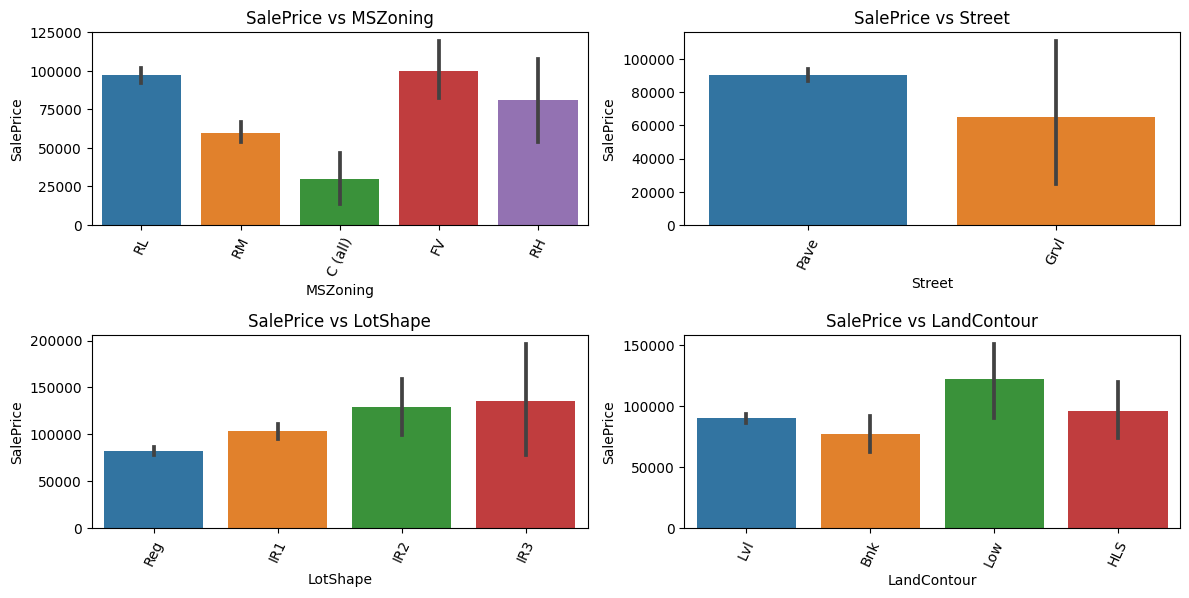

In [421]:
n_cols = 2
n_rows = (len(num_cols) + n_cols - 1) // n_cols  

plt.figure(figsize=(12, n_rows * 3))  
for k,col in enumerate(cat_cols[0:4]):
    plt.subplot(n_rows, n_cols, k+1)
    sns.barplot(x=col, y='SalePrice',data=df,estimator=np.mean)
    plt.xticks(rotation=65)
    plt.title(f"SalePrice vs {col}")
    
plt.tight_layout()  
plt.show() 

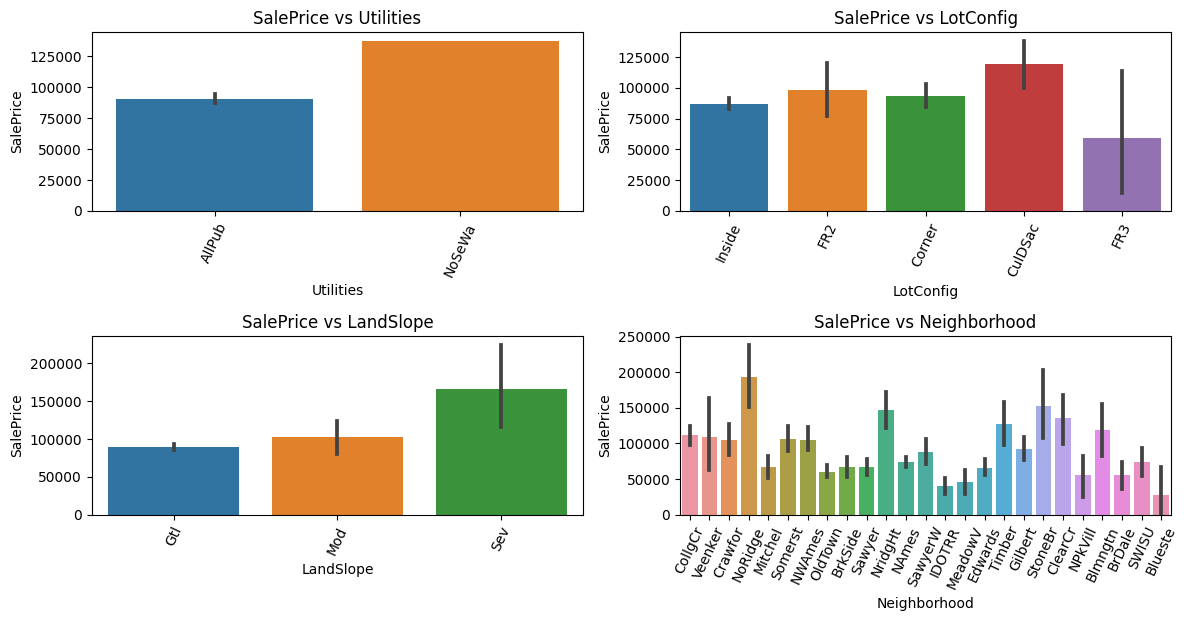

In [422]:
n_cols = 2
n_rows = (len(num_cols) + n_cols - 1) // n_cols  

plt.figure(figsize=(12, n_rows * 3))  
for k,col in enumerate(cat_cols[4:8]):
    plt.subplot(n_rows, n_cols, k+1)
    sns.barplot(x=col, y='SalePrice',data=df,estimator=np.mean)
    plt.xticks(rotation=65)
    plt.title(f"SalePrice vs {col}")
    
plt.tight_layout()  
plt.show() 

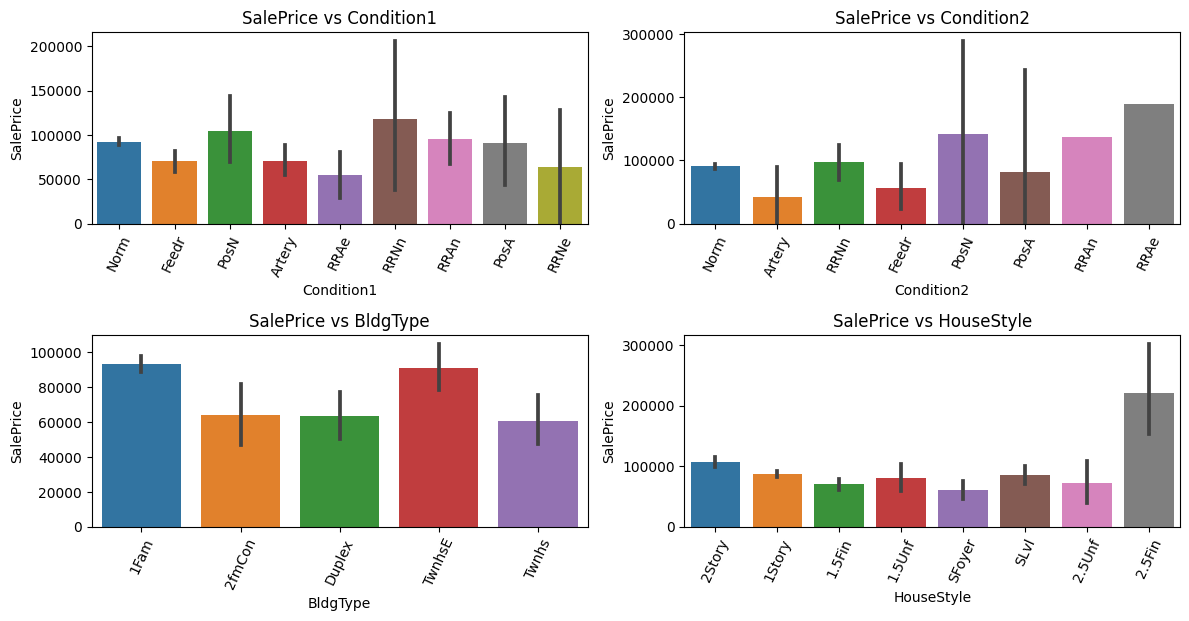

In [423]:
n_cols = 2
n_rows = (len(num_cols) + n_cols - 1) // n_cols  

plt.figure(figsize=(12, n_rows * 3))  
for k,col in enumerate(cat_cols[8:12]):
    plt.subplot(n_rows, n_cols, k+1)
    sns.barplot(x=col, y='SalePrice',data=df,estimator=np.mean)
    plt.xticks(rotation=65)
    plt.title(f"SalePrice vs {col}")
    
plt.tight_layout()  
plt.show() 

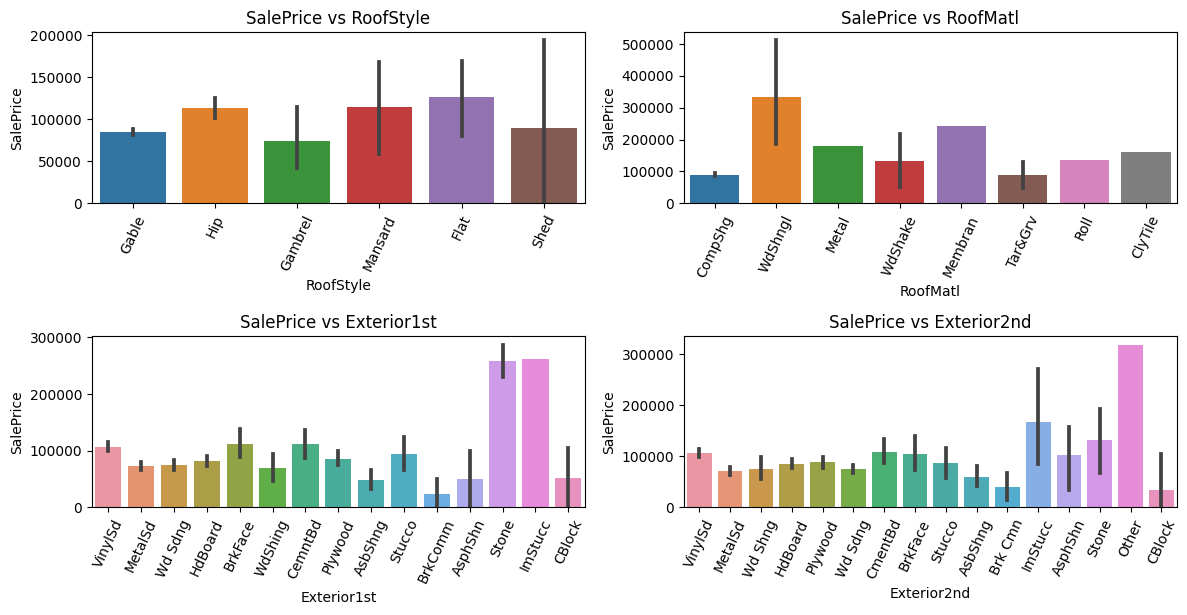

In [424]:
n_cols = 2
n_rows = (len(num_cols) + n_cols - 1) // n_cols  

plt.figure(figsize=(12, n_rows * 3))  
for k,col in enumerate(cat_cols[12:16]):
    plt.subplot(n_rows, n_cols, k+1)
    sns.barplot(x=col, y='SalePrice',data=df,estimator=np.mean)
    plt.xticks(rotation=65)
    plt.title(f"SalePrice vs {col}")
    
plt.tight_layout()  
plt.show() 

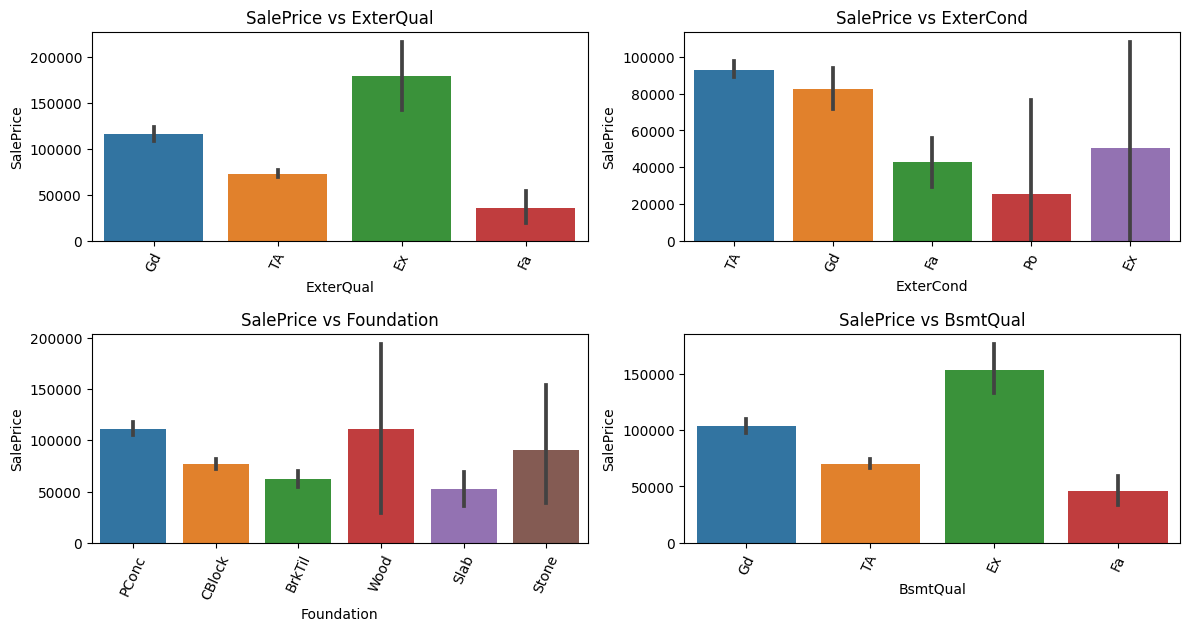

In [425]:
n_cols = 2
n_rows = (len(num_cols) + n_cols - 1) // n_cols  

plt.figure(figsize=(12, n_rows * 3))  
for k,col in enumerate(cat_cols[16:20]):
    plt.subplot(n_rows, n_cols, k+1)
    sns.barplot(x=col, y='SalePrice',data=df,estimator=np.mean)
    plt.xticks(rotation=65)
    plt.title(f"SalePrice vs {col}")
    
plt.tight_layout()  
plt.show() 

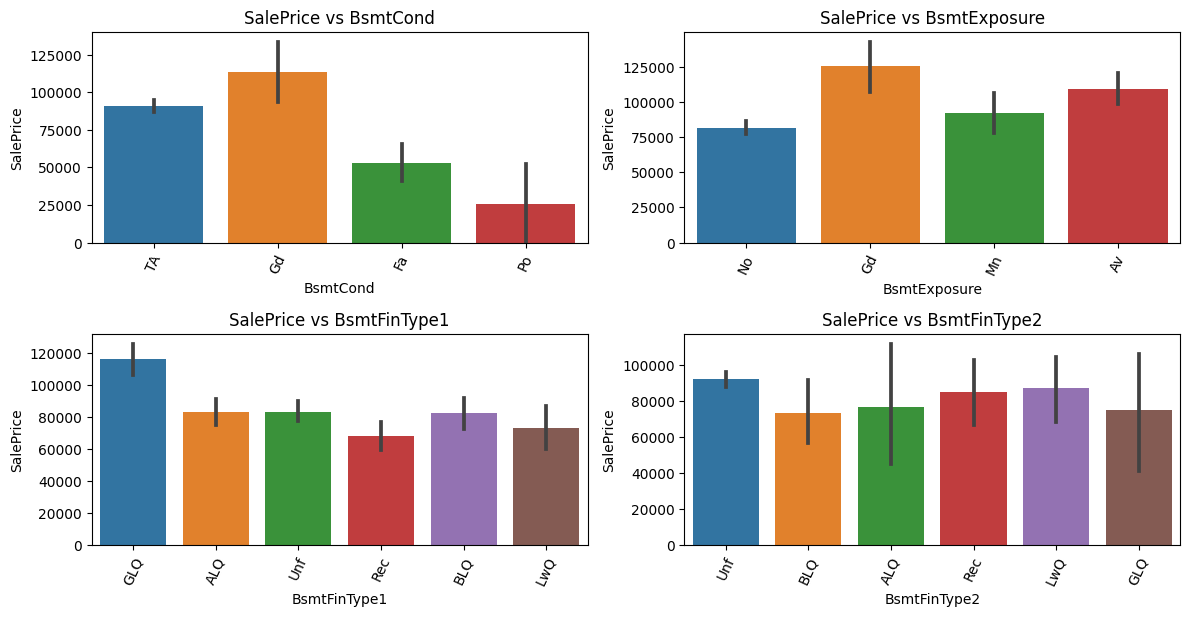

In [426]:
n_cols = 2
n_rows = (len(num_cols) + n_cols - 1) // n_cols  

plt.figure(figsize=(12, n_rows * 3))  
for k,col in enumerate(cat_cols[20:24]):
    plt.subplot(n_rows, n_cols, k+1)
    sns.barplot(x=col, y='SalePrice',data=df,estimator=np.mean)
    plt.xticks(rotation=65)
    plt.title(f"SalePrice vs {col}")
    
    
plt.tight_layout()  
plt.show() 

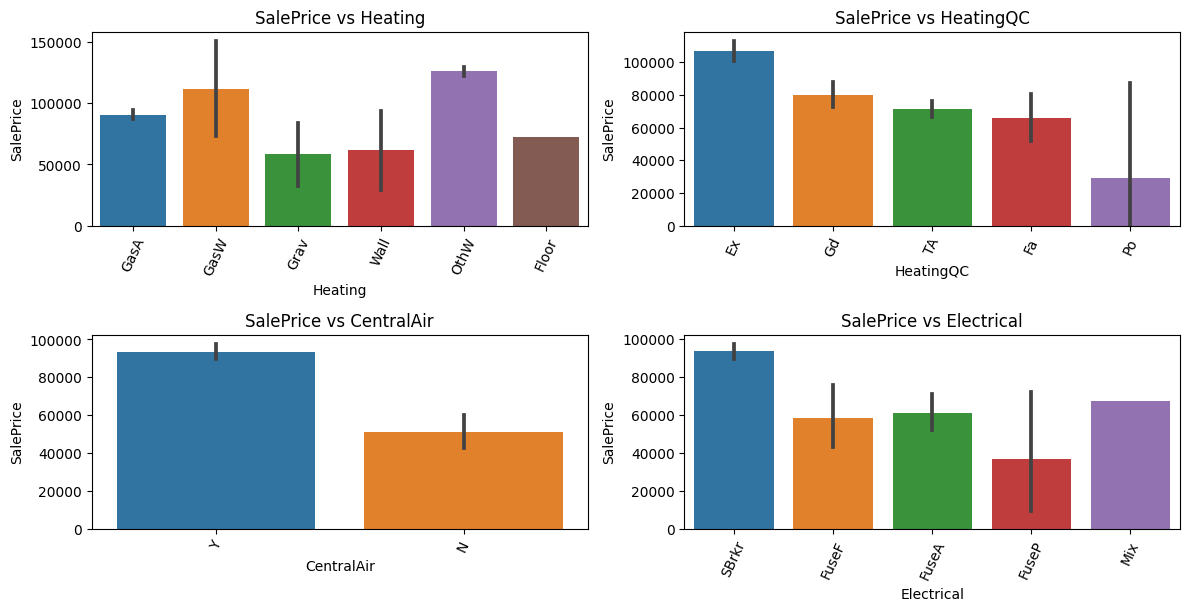

In [427]:
n_cols = 2
n_rows = (len(num_cols) + n_cols - 1) // n_cols  

plt.figure(figsize=(12, n_rows * 3))  
for k,col in enumerate(cat_cols[24:28]):
    plt.subplot(n_rows, n_cols, k+1)
    sns.barplot(x=col, y='SalePrice',data=df,estimator=np.mean)
    plt.xticks(rotation=65)
    plt.title(f"SalePrice vs {col}")
    
plt.tight_layout()  
plt.show() 

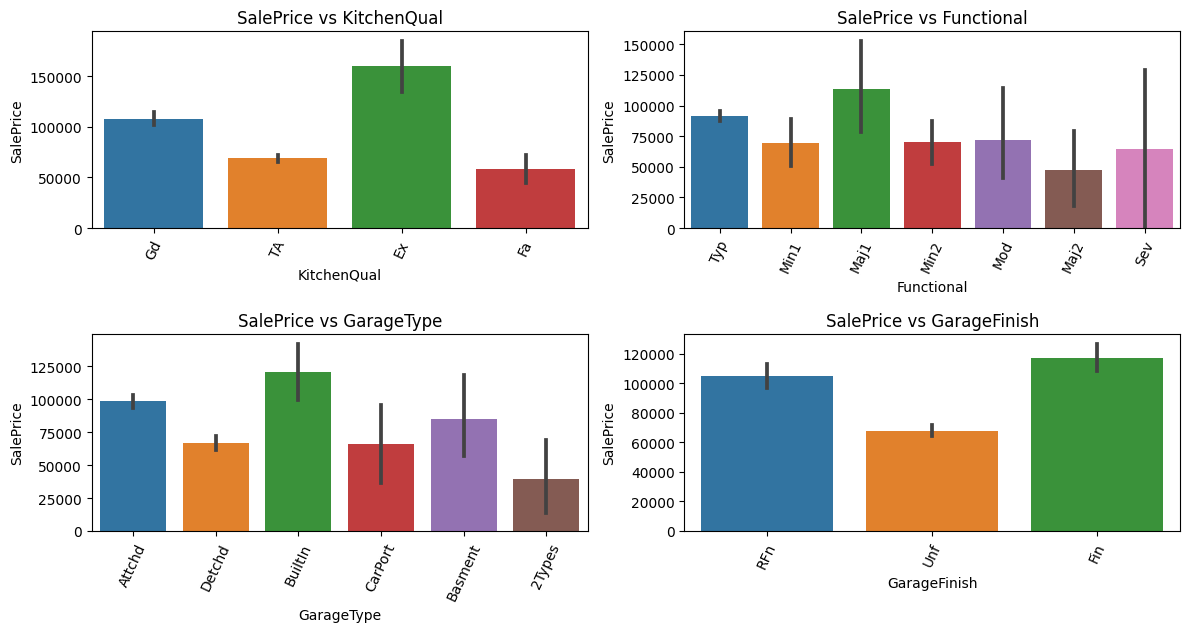

In [428]:
n_cols = 2
n_rows = (len(num_cols) + n_cols - 1) // n_cols  

plt.figure(figsize=(12, n_rows * 3))  
for k,col in enumerate(cat_cols[28:32]):
    plt.subplot(n_rows, n_cols, k+1)
    sns.barplot(x=col, y='SalePrice',data=df,estimator=np.mean)
    plt.xticks(rotation=65)
    plt.title(f"SalePrice vs {col}")
    
plt.tight_layout()  
plt.show() 

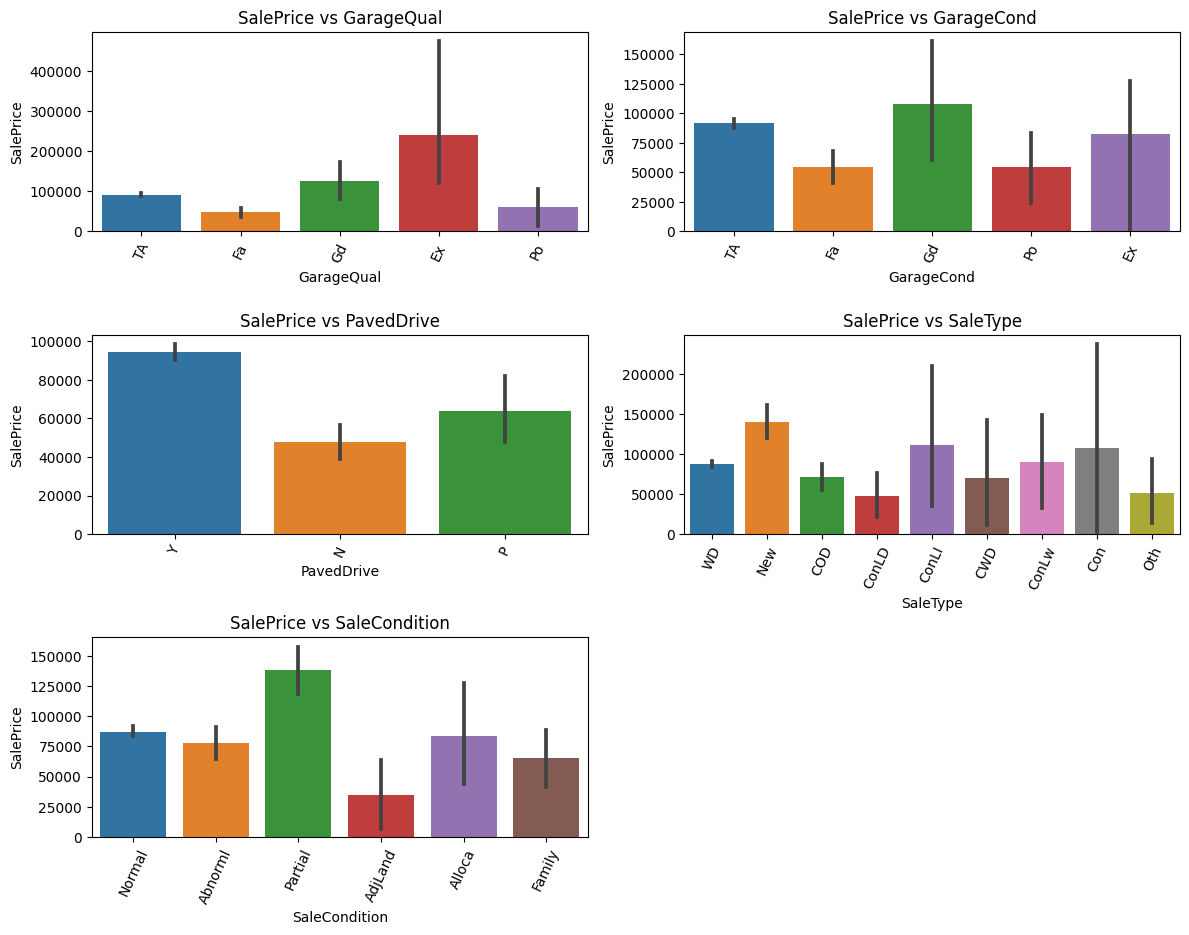

In [429]:
n_cols = 2
n_rows = (len(num_cols) + n_cols - 1) // n_cols  

plt.figure(figsize=(12, n_rows * 3))  
for k,col in enumerate(cat_cols[32:]):
    plt.subplot(n_rows, n_cols, k+1)
    sns.barplot(x=col, y='SalePrice',data=df,estimator=np.mean)
    plt.xticks(rotation=65)
    plt.title(f"SalePrice vs {col}")
    
plt.tight_layout()  
plt.show() 

<Axes: >

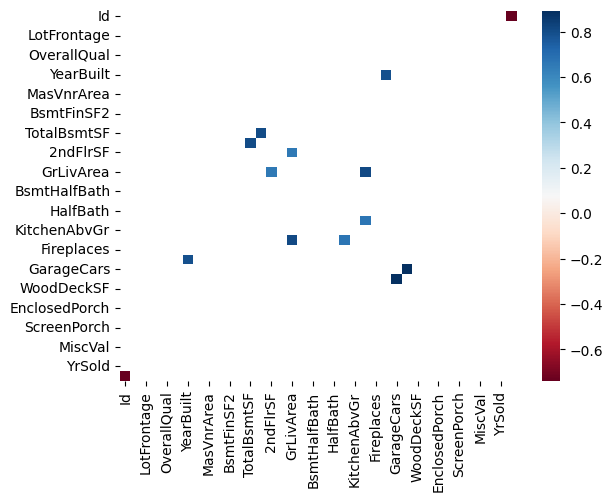

In [430]:
corr=df[num_cols].corr()
filtered_corr = corr[(abs(corr)>0.65) & (corr<1)]
sns.heatmap(data=filtered_corr,annot=False, cmap = "RdBu")

In [431]:
correlated_pairs = filtered_corr.stack().reset_index()
correlated_pairs.columns = ['Column 1', 'Column 2', 'Correlation']
correlated_pairs

,Column 1,Column 2,Correlation
0,Id,SalePrice,-0.739838
1,YearBuilt,GarageYrBlt,0.788253
2,TotalBsmtSF,1stFlrSF,0.801638
3,1stFlrSF,TotalBsmtSF,0.801638
4,2ndFlrSF,GrLivArea,0.655085
5,GrLivArea,2ndFlrSF,0.655085
6,GrLivArea,TotRmsAbvGrd,0.808354
7,BedroomAbvGr,TotRmsAbvGrd,0.669737
8,TotRmsAbvGrd,GrLivArea,0.808354
9,TotRmsAbvGrd,BedroomAbvGr,0.669737


## Encoding


In [432]:
import category_encoders as ce

In [433]:
freq_code = []
dummy_code = []
for col in cat_cols:
    length=len(df[col].value_counts().index)
    if length>4:
        freq_code.append(col)
    else:
        dummy_code.append(col)

In [434]:
dummy = ce.OneHotEncoder(cols=dummy_code)
freq = ce.CountEncoder(cols=freq_code)
targ = ce.TargetEncoder()
df_new = df.copy()
df_new = df_new.drop(columns=cat_cols,axis=1)
df_dummy = dummy.fit_transform(df[['Street','LotShape','LandContour','Utilities',
                                   'LandSlope','ExterQual','BsmtQual','BsmtCond',
                                   'BsmtExposure','CentralAir','KitchenQual','GarageFinish',
                                   'PavedDrive']])
df_new = pd.concat([df_new,df_dummy],axis=1)

df_dummy = freq.fit_transform(df[['MSZoning','LotConfig','Neighborhood','Condition1','Condition2',
                                  'BldgType','HouseStyle','RoofStyle','RoofMatl','Exterior1st',
                                  'Exterior2nd','ExterCond','Foundation','BsmtFinType1','BsmtFinType2',
                                  'Heating','HeatingQC','Electrical','Functional','GarageType','GarageQual',
                                  'GarageCond','SaleType','SaleCondition']])
df_new = pd.concat([df_new,df_dummy],axis=1)
df_new.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,Street_1,Street_2,LotShape_1,LotShape_2,LotShape_3,LotShape_4,LandContour_1,LandContour_2,LandContour_3,LandContour_4,Utilities_1,Utilities_2,LandSlope_1,LandSlope_2,LandSlope_3,ExterQual_1,ExterQual_2,ExterQual_3,ExterQual_4,BsmtQual_1,BsmtQual_2,BsmtQual_3,BsmtQual_4,BsmtCond_1,BsmtCond_2,BsmtCond_3,BsmtCond_4,BsmtExposure_1,BsmtExposure_2,BsmtExposure_3,BsmtExposure_4,CentralAir_1,CentralAir_2,KitchenQual_1,KitchenQual_2,KitchenQual_3,KitchenQual_4,GarageFinish_1,GarageFinish_2,GarageFinish_3,PavedDrive_1,PavedDrive_2,PavedDrive_3,MSZoning,LotConfig,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,ExterCond,Foundation,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,Electrical,Functional,GarageType,GarageQual,GarageCond,SaleType,SaleCondition
0,1,60,65.0,8450,7,5,2003,2003,196.0,706.0,0.0,150.0,856.0,856,854,0,1710,1.0,0.0,2,1,3,1,8,0,2003.0,2.0,548.0,0,61,0,0,0,0,0,2,2008,208500.0,1,0,1,0,0,0,1,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,2269,2133,267,2511,2889,2425,872,2310,2876,1026,1015,2538,1308,849,2573,2874,1493,2672,2719,1880,2763,2813,2526,2402
1,2,20,80.0,9600,6,8,1976,1976,0.0,978.0,0.0,284.0,1262.0,1262,0,0,1262,0.0,1.0,2,0,3,1,6,1,1976.0,2.0,460.0,298,0,0,0,0,0,0,5,2007,181500.0,1,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,2269,85,24,164,2889,2425,1471,2310,2876,450,447,2538,1235,429,2573,2874,1493,2672,2719,1880,2763,2813,2526,2402
2,3,60,68.0,11250,7,5,2001,2002,162.0,486.0,0.0,434.0,920.0,920,866,0,1786,1.0,0.0,2,1,3,1,6,1,2001.0,2.0,608.0,0,42,0,0,0,0,0,9,2008,223500.0,1,0,0,1,0,0,1,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,1,0,0,0,1,0,0,1,0,0,2269,2133,267,2511,2889,2425,872,2310,2876,1026,1015,2538,1308,849,2573,2874,1493,2672,2719,1880,2763,2813,2526,2402
3,4,70,60.0,9550,7,5,1915,1970,0.0,216.0,0.0,540.0,756.0,961,756,0,1717,1.0,0.0,1,0,3,1,7,1,1998.0,3.0,642.0,0,35,272,0,0,0,0,2,2006,140000.0,1,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,1,0,0,2269,511,103,2511,2889,2425,872,2310,2876,411,81,2538,311,429,2573,2874,474,2672,2719,779,2763,2813,2526,190
4,5,60,84.0,14260,8,5,2000,2000,350.0,655.0,0.0,490.0,1145.0,1145,1053,0,2198,1.0,0.0,2,1,4,1,9,1,2000.0,3.0,836.0,192,84,0,0,0,0,0,12,2008,250000.0,1,0,0,1,0,0,1,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,1,0,1,0,0,0,1,0,0,1,0,0,2269,85,71,2511,2889,2425,872,2310,2876,1026,1015,2538,1308,849,2573,2874,1493,2672,2719,1880,2763,2813,2526,2402


In [435]:
print(train.shape)
print(test.shape)

(1460, 81)
(1459, 80)


In [436]:
train_df = df_new.iloc[0:1460]
test_df = df_new.iloc[1460:]
test_df = test_df.drop(columns='SalePrice',axis=1)
test_df.reset_index(inplace=True,drop=True)

In [437]:
print(train_df.shape)
print(test_df.shape)

(1460, 105)
(1459, 104)


## Model Building

In [438]:
from sklearn.model_selection import cross_val_predict, RandomizedSearchCV, GridSearchCV
from scipy.stats import randint,uniform
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error as mse
from xgboost import XGBRegressor 


In [439]:
xtrain = train_df.drop(columns=['Id','SalePrice'],axis=1)
ytrain = train_df['SalePrice']

In [440]:
xgb = XGBRegressor(objective='reg:squarederror', n_estimators=100)

xgb.fit(xtrain,ytrain)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [441]:
ypred=cross_val_predict(xgb,xtrain,ytrain,cv=5)
print('cross-validation-rmse of XGB',np.sqrt(mse(ytrain,ypred)))

cross-validation-rmse of XGB 27631.076718934328


In [ ]:
xgb = XGBRegressor()

xgb_param_grid = {
    'n_estimators':[100,200],
    'max_depth':randint(3,10),
    'learning_rate':uniform(0.01,0.3),
    'subsample': uniform(0.7,0.9)
}

xgb_search = RandomizedSearchCV(estimator=xgb,param_distributions=xgb_param_grid,
                                scoring='neg_mean_squared_error',cv=3,
                               n_iter=50,random_state=11,verbose=1)

xgb_search.fit(xtrain,ytrain)

In [ ]:
best_xgb_model = xgb_search.best_estimator_
best_ypred=cross_val_predict(best_xgb_model,xtrain,ytrain,cv=5)
print('cross-validation-rmse of Tuned XGB ',np.sqrt(mse(ytrain,best_ypred)))

In [ ]:
# GridSearchCV
xgb_params = {'n_estimators': [100, 200],
    'max_depth': [3, 5, 7,10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8,0.9]}
grid_search = GridSearchCV(estimator=xgb, param_grid=xgb_params, 
                           scoring='neg_mean_squared_error', 
                           cv=5, verbose=1, n_jobs=-1)

# Fit the model
grid_search.fit(xtrain, ytrain)

In [ ]:
xgb_gridcv = grid_search.best_estimator_
print("Best Score:", np.sqrt(abs(grid_search.best_score_)))


In [ ]:
grid_search.best_params_

In [442]:
model = XGBRegressor()

param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'n_estimators': [100, 200]
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='neg_root_mean_squared_error', cv=5)
grid_search.fit(xtrain, ytrain)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=None, ...),
             param_grid={'colsample_bytree': [0.6, 0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'min_child_weight': [1, 3, 5],
                         'n_estimators': [100, 200],
                         'subsample': [0.6, 0.8, 1.0]},
             scoring='neg_root_mean_squared_error')

In [456]:
lgb = grid_search.best_estimator_
print("Best Score:", grid_search.best_score_)

Best Score: -26540.188873603525


In [455]:
import lightgbm as lgb

model = lgb.LGBMRegressor()

# Define the hyperparameter grid
param_grid = {
    'boosting_type': ['gbdt', 'dart'],
    'num_leaves': [31, 50, 100],
    'max_depth': [-1, 5, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid,
                           scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1,verbose=1)

# Fit the model
grid_search.fit(xtrain, ytrain)

# Best parameters and score
print("Best hyperparameters: ", grid_search.best_params_)
print("Best RMSE: ", -grid_search.best_score_)

Fitting 5 folds for each of 1458 candidates, totalling 7290 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001292 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3407
[LightGBM] [Info] Number of data points in the train set: 1460, number of used features: 93
[LightGBM] [Info] Start training from score 180921.195890
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [459]:
preds = xgb_2.predict(test_df.drop(columns='Id',axis=1))
preds

array([126915.81, 151549.4 , 188453.08, ..., 172662.86, 117753.26,
       224050.47], dtype=float32)

In [460]:
submission = pd.concat([test_df['Id'],pd.Series(preds)],axis=1,ignore_index=True)
submission.columns = ['Id','SalePrice']
submission.head()

,Id,SalePrice
0,1461,126915.812500
1,1462,151549.406250
2,1463,188453.078125
3,1464,185468.812500
4,1465,182439.234375


In [452]:
submission1.to_csv('lgbm2.csv',index=False)

## Finished..